In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')
df.columns = df.columns.str.lower().str.replace(' ','_')

strings = list(df.dtypes[df.dtypes == 'object'].index)
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ','_')

In [11]:
#Question 1
df.isnull().sum()[df.isnull().sum() > 0]

num_cylinders    482
horsepower       708
acceleration     930
num_doors        502
dtype: int64

In [13]:
#Question 2. Median for horse power
df['horsepower'].median()

149.0

In [ ]:
# Question 3

In [87]:
def train_linear_regression(X,Y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(Y)

    return w_full[0], w_full[1:]

def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range (n):
        res = res + xi[j] * w[j]

    return res 
    
def rmse(Y, Y_pred):
    se = (Y - Y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [64]:
list(df.dtypes[df.dtypes != 'object'].index)

['engine_displacement',
 'num_cylinders',
 'horsepower',
 'vehicle_weight',
 'acceleration',
 'model_year',
 'num_doors',
 'fuel_efficiency_mpg']

In [69]:
target = 'fuel_efficiency_mpg'

In [70]:
# Shuffle the dataset with seed 42
np.random.seed(42)
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx].copy()

# Split the data
df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train + n_val].copy()
df_test = df_shuffled.iloc[n_train + n_val:].copy()

# Reset indices
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Separate target variables
Y_train = df_train[target].values
Y_val = df_val[target].values
Y_test = df_test[target].values

In [81]:

base = list(df.dtypes[df.dtypes != 'object'].index)
X_train = df_train[base].fillna(0).values
X_val = df_val[base].fillna(0).values
Y_train = df_train[target].values
Y_val = df_val[target].values
w0, w = train_linear_regression(X_train,Y_train)
Y_pred = w0 + X_val.dot(w)


<Axes: ylabel='Count'>

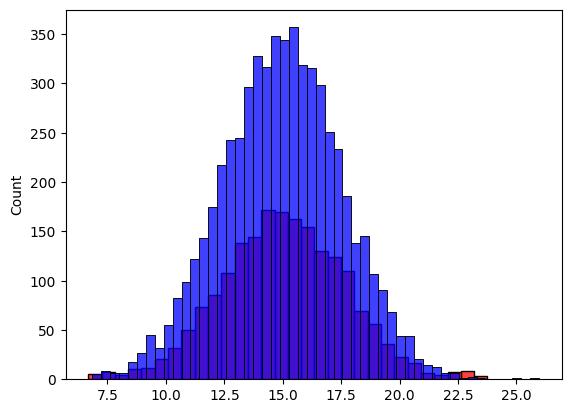

In [82]:
sns.histplot(Y_pred, color='red')
sns.histplot(Y_train, color='blue')


In [91]:
rmse_val = rmse(Y_val, Y_pred)
rmse_rounded = round(rmse_val, 2)
print(f"RMSE rounded para la opción 'Fill with 0': {rmse_rounded}")
print(f"RMSE not rounded para la opción 'Fill with 0': {rmse_val}")

RMSE rounded para la opción 'Fill with 0': 0.0
RMSE not rounded para la opción 'Fill with 0': 1.2754370888545153e-10


In [98]:
missing_col = 'fuel_efficiency_mpg'
mean_hp_train = df_train[missing_col].mean()

In [105]:
# Asegúrate de haber ejecutado todo el código de carga, limpieza y división.

# ----------------------------------------------------
# Opción 1: Llenar con 0
# ----------------------------------------------------
print("--- Opción 1: Llenar con 0 ---")

# 1. Preparar las características: Llenar NaNs con 0
# Asumimos que 'base' contiene la lista de características numéricas.
X_train_0 = df_train[base].fillna(0).values
X_val_0 = df_val[base].fillna(0).values

# 2. Entrenar el modelo
w0_0, w_0 = train_linear_regression(X_train_0, Y_train)

# 3. Predecir en el conjunto de validación
Y_pred_0 = w0_0 + X_val_0.dot(w_0)

# 4. Evaluar el RMSE
rmse_0 = rmse(Y_val, Y_pred_0)
rmse_0_rounded = round(rmse_0, 2)

print(f"RMSE (Rounded) para la opción 'Fill with 0': {rmse_0_rounded}")
print("-" * 30)

--- Opción 1: Llenar con 0 ---
RMSE (Rounded) para la opción 'Fill with 0': 0.0
------------------------------


In [103]:
# ----------------------------------------------------
# Opción 2: Llenar con Media (del entrenamiento)
# ----------------------------------------------------
print("--- Opción 2: Llenar con la Media del Entrenamiento ---")

# 1. Calcular la media (SOLO en el conjunto de entrenamiento y SOLO en 'horsepower')
# Asumo 'horsepower' es la columna con NaNs
mean_hp_train = df_train['horsepower'].mean()

print(f"Media de 'horsepower' (solo entrenamiento): {round(mean_hp_train, 2)}")

# 2. Preparar las características: Llenar NaNs con la media calculada
# Nota: Usamos fillna({'columna': valor}) para imputar solo esa columna
X_train_mean = df_train[base].fillna({'horsepower': mean_hp_train}).values
X_val_mean = df_val[base].fillna({'horsepower': mean_hp_train}).values

# 3. Entrenar el modelo
# NOTA: Se entrena un modelo COMPLETAMENTE NUEVO
w0_mean, w_mean = train_linear_regression(X_train_mean, Y_train)

# 4. Predecir en el conjunto de validación
Y_pred_mean = w0_mean + X_val_mean.dot(w_mean)

# 5. Evaluar el RMSE
rmse_mean = rmse(Y_val, Y_pred_mean)
rmse_mean_rounded = round(rmse_mean, 2)

print(f"RMSE (Rounded) para la opción 'Fill with mean': {rmse_mean_rounded}")
print("-" * 30)

--- Opción 2: Llenar con la Media del Entrenamiento ---
Media de 'horsepower' (solo entrenamiento): 149.54
RMSE (Rounded) para la opción 'Fill with mean': nan
------------------------------


In [104]:
# ----------------------------------------------------
# Comparación
# ----------------------------------------------------

print(f"RMSE (Fill with 0): {rmse_0_rounded}")
print(f"RMSE (Fill with mean): {rmse_mean_rounded}")

if rmse_0_rounded < rmse_mean_rounded:
    print("La opción 'Fill with 0' es mejor.")
elif rmse_mean_rounded < rmse_0_rounded:
    print("La opción 'Fill with mean' es mejor.")
else:
    print("Ambas son igualmente buenas.")

RMSE (Fill with 0): 0.0
RMSE (Fill with mean): nan
Ambas son igualmente buenas.


In [106]:
# Question 4

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Supongo que df_train, df_val, Y_train, Y_val y la lista 'base'
# ya están definidos y cargados del código anterior

# Definición de las funciones (debes asegurarte de que estén ejecutadas)
def train_linear_regression(X, Y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(Y)

    return w_full[0], w_full[1:]

def train_linear_regression_reg(X, Y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(Y)

    return w_full[0], w_full[1:]

def rmse(Y, Y_pred):
    se = (Y - Y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

# ----------------------------------------------------
# PREPARACIÓN Y ENTRENAMIENTO
# ----------------------------------------------------

# Imputación de NAs con 0 (según el requisito)
X_train = df_train[base].fillna(0).values
X_val = df_val[base].fillna(0).values

# Lista de valores r
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_scores = {}

for r in r_values:
    # Entrenar el modelo regularizado
    w0, w = train_linear_regression_reg(X_train, Y_train, r=r)

    # Predecir en el conjunto de validación
    Y_pred = w0 + X_val.dot(w)

    # Evaluar el RMSE
    score = rmse(Y_val, Y_pred)
    rmse_scores[r] = round(score, 2)

# Encontrar el mejor r
best_r = min(rmse_scores, key=rmse_scores.get)
best_rmse = rmse_scores[best_r]

# Imprimir los resultados en el formato requerido
print(rmse_scores)
print(f"Mejor r: {best_r} con RMSE: {best_rmse}")

{0: np.float64(0.0), 0.01: np.float64(0.0), 0.1: np.float64(0.0), 1: np.float64(0.0), 5: np.float64(0.0), 10: np.float64(0.0), 100: np.float64(0.03)}
Mejor r: 0 con RMSE: 0.0


In [108]:
#Question 5 
import pandas as pd
import numpy as np

# Supongo que las funciones train_linear_regression y rmse están definidas
# (debes asegurarte de que están ejecutadas en tu entorno)

def train_linear_regression(X, Y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(Y)

    return w_full[0], w_full[1:]

def rmse(Y, Y_pred):
    se = (Y - Y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

# Asumo que 'df' (dataframe original preprocesado) y 'base' (lista de features)
# y 'target' (columna objetivo) están definidos del código anterior

# Lista de semillas a probar
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []

n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_val - n_test

for seed in seeds:
    # 1. División y Mezcla (Shuffle)
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_shuffled = df.iloc[idx].copy()

    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train + n_val].copy()
    
    # 2. Preparar Features y Target
    # Llenar NAs con 0 (requisito del problema)
    X_train = df_train[base].fillna(0).values
    X_val = df_val[base].fillna(0).values

    Y_train = df_train[target].values
    Y_val = df_val[target].values

    # 3. Entrenar el modelo (sin regularización, r=0)
    w0, w = train_linear_regression(X_train, Y_train)

    # 4. Predecir en el conjunto de validación
    Y_pred = w0 + X_val.dot(w)

    # 5. Evaluar y guardar el RMSE
    score = rmse(Y_val, Y_pred)
    rmse_scores.append(score)

# 6. Calcular la desviación estándar
std_rmse = np.std(rmse_scores)
std_rounded = round(std_rmse, 3)

# 7. Imprimir el resultado (sin comentarios)
print(std_rounded)

0.0


In [109]:
#Question 6
import numpy as np
import pandas as pd

# Definición de las funciones de entrenamiento y evaluación (como en las lecciones)
def train_linear_regression_reg(X, Y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(Y)

    return w_full[0], w_full[1:]

def rmse(Y, Y_pred):
    se = (Y - Y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

# Asumo que 'df' (dataframe original preprocesado) y 'base', 'target' están definidos

# Parámetros
seed = 9
r_value = 0.001
distribution = 0.2 # 20% para val y test

# 1. División del conjunto de datos con seed=9
np.random.seed(seed)
n = len(df)
n_val = int(distribution * n)
n_test = int(distribution * n)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx].copy()

df_train = df_shuffled.iloc[:n_train].copy().reset_index(drop=True)
df_val = df_shuffled.iloc[n_train:n_train + n_val].copy().reset_index(drop=True)
df_test = df_shuffled.iloc[n_train + n_val:].copy().reset_index(drop=True)

# 2. Combinar conjuntos de entrenamiento y validación
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)

# 3. Preparar Features y Target del conjunto completo de entrenamiento
# Llenar NAs con 0 (requisito del problema)
X_full_train = df_full_train[base].fillna(0).values
Y_full_train = df_full_train[target].values

# 4. Entrenar el modelo con r=0.001
w0, w = train_linear_regression_reg(X_full_train, Y_full_train, r=r_value)

# 5. Preparar el conjunto de prueba y evaluar
X_test = df_test[base].fillna(0).values
Y_test = df_test[target].values

# Predecir en el conjunto de prueba
Y_pred_test = w0 + X_test.dot(w)

# Evaluar el RMSE en el conjunto de prueba
rmse_test = rmse(Y_test, Y_pred_test)

# Redondear el resultado para la comparación
rmse_test_rounded = round(rmse_test, 3)

# Mostrar el resultado final (sin comentarios)
print(rmse_test_rounded)

0.0
